# w_inst calibration helper

Pick production constraints for the BH fitter (`w_inst_default`, `w_inst_bounds`, optionally `fix_w_inst`, plus `dx_tol_nm` and `base_bound`) by **inspecting** the distribution of free-fit parameters over a small set of representative spectra.

**This notebook is intentionally manual.**  It does not auto-pick bounds.  You decide whether the histograms support a tighter constraint or a fixed value.

Procedure:

1. Pick a few representative shots (`SHOTS`) and an explicit (small) set of `FRAMES` / `CHANNELS`.
2. Run `run_folder_batch` or `run_bh_batch` with **loose** `w_inst_bounds` (this notebook uses `run_folder_batch`).
3. Use `summarize_fit_distribution` + `plot_fit_distributions` to inspect `w_inst`, `dx`, `base`.
4. Optionally overlay candidate bounds on the histograms.
5. Adopt the chosen values explicitly in `examples/12_batch_batch.ipynb` (`W_INST_DEFAULT`, `W_INST_BOUNDS`, ...) or in your YAML config.

In [17]:
from pathlib import Path

DATA_DIR = Path("~/Dropbox/Experiments/2025-LHD-BH/133mORCA").expanduser()
OUT_DIR = Path("bh_calibration_results")

SHOTS = [193788]
FRAMES = [6, 7, 8, 9, 10]
CHANNELS = [5, 27, 28, 29, 30]

BACKGROUND_FRAMES = (0, 1, 2, 3)
BH_FIT_WAVELENGTH_RANGE_NM = (433.05, 433.90)
BH_SCALE_WAVELENGTH_RANGE_NM = (433.08, 433.30)

CW_NM = 431.91
SCALE = 1.0
TIME_RANGE = (0.0, 10.0)

# Loose w_inst bounds for the calibration scan.  Keep generous; we want
# to see where the optimizer naturally lands.
LOOSE_W_INST_BOUNDS = (0.005, 0.06)

# Optional R2 quality cut when summarizing.
R2_MIN = 0.5

# Candidate bounds you want to overlay on the histograms (or None).
CANDIDATE_BOUNDS = {
    "w_inst": (0.017, 0.022),
    "dx": (-0.02, 0.02),
    "base": (0.0, 0.1),
}

In [2]:
from bh_molecule import run_folder_batch
from bh_molecule.workflows.calibration import (
    summarize_fit_distribution,
    plot_fit_distributions,
)

out_dir = OUT_DIR if OUT_DIR.is_absolute() else (Path.cwd() / OUT_DIR).resolve()
print(f"Output folder:           {out_dir}")
print(f"Shots:                   {SHOTS}")
print(f"Frames:                  {FRAMES}")
print(f"Channels:                {CHANNELS}")
print(f"Background frames:       {BACKGROUND_FRAMES}")
print(f"BH fit window:           {BH_FIT_WAVELENGTH_RANGE_NM} nm")
print(f"BH scale window:         {BH_SCALE_WAVELENGTH_RANGE_NM} nm")
print(f"Loose w_inst bounds:     {LOOSE_W_INST_BOUNDS} nm")

results = run_folder_batch(
    DATA_DIR,
    frames=FRAMES,
    channels=CHANNELS,
    shots=SHOTS,
    cw=CW_NM,
    scale=SCALE,
    time_range=TIME_RANGE,
    background_frames=BACKGROUND_FRAMES,
    bh_fit_range=BH_FIT_WAVELENGTH_RANGE_NM,
    bh_scale_range=BH_SCALE_WAVELENGTH_RANGE_NM,
    w_inst_bounds=LOOSE_W_INST_BOUNDS,
    fix_w_inst=False,
    out_dir=out_dir,
    save_frames=False,
)
list(results.keys())

Output folder:           C:\Users\queezz\Dropbox\20-Code\2025-bh-molecule\examples\bh_calibration_results
Shots:                   [193788]
Frames:                  [6, 7, 8, 9, 10]
Channels:                [5, 27, 28, 29, 30]
Background frames:       (0, 1, 2, 3)
BH fit window:           (433.05, 433.9) nm
BH scale window:         (433.08, 433.3) nm
Loose w_inst bounds:     (0.005, 0.06) nm
Processing 1 shot(s) under C:\Users\queezz\Dropbox\Experiments\2025-LHD-BH\133mORCA
--- [193788] (1/1) ---
Processing shot 193788: C:\Users\queezz\Dropbox\Experiments\2025-LHD-BH\133mORCA\193788.fits
Output: C:\Users\queezz\Dropbox\20-Code\2025-bh-molecule\examples\bh_calibration_results\193788
background_frames: (0, 1, 2, 3)
save_frames: False
BH fit window: [433.05, 433.9] nm
BH scale window: [433.08, 433.3] nm
Frame PNG saving disabled.
Background frames look flat (ratio = 0.03)
Using frames [6, 7, 8, 9, 10]
Using channels [5, 27, 28, 29, 30]
Fitter constraints: w_inst_default=0.0250 nm, w_inst_

Fits:   0%|          | 0/25 [00:00<?, ?it/s]

Finished shot 193788
Summary: C:\Users\queezz\Dropbox\20-Code\2025-bh-molecule\examples\bh_calibration_results\193788\summary.csv
Grid: C:\Users\queezz\Dropbox\20-Code\2025-bh-molecule\examples\bh_calibration_results\193788\grid.pdf


['193788']

In [3]:
import pandas as pd

frames_list = []
for shot_id, df_shot in results.items():
    if df_shot is None or df_shot.empty:
        continue
    d = df_shot.copy()
    d["shot"] = shot_id
    frames_list.append(d)

if frames_list:
    df = pd.concat(frames_list, ignore_index=True)
else:
    # Fallback: read the on-disk CSVs (resume path).
    dfs = []
    for shot in SHOTS:
        csv = out_dir / str(shot) / "summary.csv"
        if csv.is_file():
            d = pd.read_csv(csv)
            d["shot"] = str(shot)
            dfs.append(d)
    df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print(f"Total fits: {len(df)}")
df.head()

Total fits: 25


,frame,channel,C,T_rot,dx,w_inst,base,I_R7,I_R8,C_err,T_rot_err,dx_err,w_inst_err,base_err,I_R7_err,I_R8_err,chi2_red,R2,npts,shot
0,6,5,0.988845,2694.749680,0.016924,0.018692,0.03,0.002051,0.000919,0.088501,330.162778,0.000689,0.001726,0.007011,0.000928,0.000920,0.012055,0.705662,356,193788
1,6,27,0.952408,2955.994949,-0.000460,0.018515,0.03,0.002100,0.001141,0.042695,192.819255,0.000334,0.000837,0.003676,0.000479,0.000475,0.003245,0.901431,356,193788
2,6,28,0.819467,3288.616664,-0.000315,0.018543,0.03,0.001411,0.000748,0.037636,236.694923,0.000338,0.000852,0.003575,0.000460,0.000457,0.003003,0.893615,356,193788
3,6,29,0.938056,2747.818696,-0.000254,0.017896,0.03,0.001095,0.000744,0.038808,156.955657,0.000306,0.000770,0.003144,0.000407,0.000405,0.002445,0.915572,356,193788
4,6,30,0.847843,3329.344823,0.000396,0.018389,0.03,0.001248,0.000949,0.033900,210.130042,0.000293,0.000737,0.003265,0.000418,0.000416,0.002503,0.916962,356,193788


In [4]:
summary = summarize_fit_distribution(
    df, params=("w_inst", "dx", "base"), r2_min=R2_MIN
)
print(f"--- summary (R2 >= {R2_MIN}) ---")
summary

--- summary (R2 >= 0.5) ---


,n,median,mad,p05,p16,p50,p84,p95,min,max
param,,,,,,,,,,
w_inst,23,0.018692,0.000610,0.017294,0.017993,0.018692,0.020307,0.024636,0.016952,0.025780
dx,23,-0.000195,0.000182,-0.000625,-0.000508,-0.000195,0.017018,0.017168,-0.000777,0.017675
base,23,0.030000,0.000000,0.030000,0.030000,0.030000,0.030000,0.030000,0.030000,0.030000


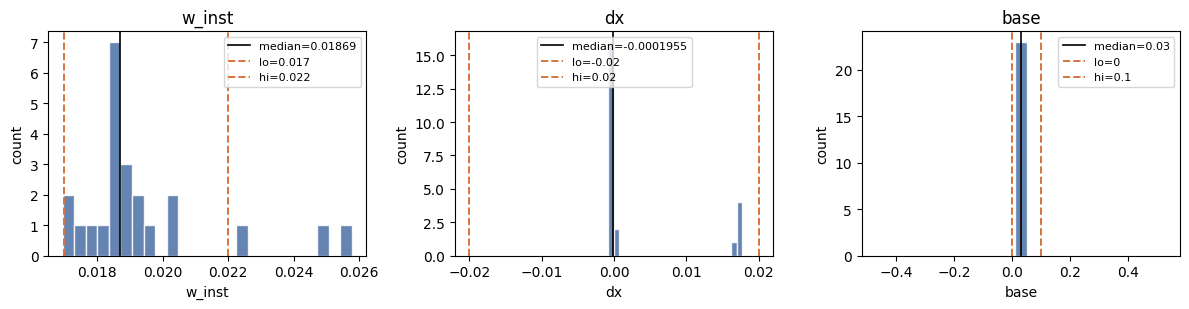

In [18]:
fig, axes = plot_fit_distributions(
    df,
    params=("w_inst", "dx", "base"),
    suggested_bounds=CANDIDATE_BOUNDS,
    bins=25,
    r2_min=R2_MIN,
)

## Adopt production constraints

Inspect the summary table and histograms above.  Reasonable production rules:

- If `w_inst` clusters tightly around a single value across frames/channels with low MAD, consider either:
  - tight bounds: `w_inst_bounds = (p16, p84)` or a slightly wider hand-picked interval, **or**
  - a fixed value: `fix_w_inst = True` with `w_inst_default = median`.
- If `dx` stays well inside a narrow window, lower `dx_tol_nm` accordingly (but keep some slack for CW drift).
- If `base` already sits near zero, the default `base_bound = 0.03` is usually fine.

Then copy the chosen values into `examples/12_batch_batch.ipynb` (the `W_INST_*`, `DX_TOL_NM`, `BASE_BOUND` cell) or into your YAML config.

**Do not** push automatic bound selection: keep the choice explicit and reviewable.